# Week 5, Tutorial 3: Exploratory Visualisation

**Author**: Sariana Ramoutar

This notebook creates the visualisations used to understand the cleaned emergency department dataset. These plots summarise data quality, patient demographics, chief complaints, vital signs and relationships between variables, providing evidence for the feasibility memo.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br>Build the six-plot dashboard yourself. Each plot cell below outlines the required pandas/matplotlib calls. Complete these to generate and save each figure to <code>figs/</code>.</div>

## Import libraries and load the cleaned dataset

The notebook imports the required libraries, loads the cleaned dataset (or rebuilds it if necessary), recreates the column families, and prepares everything needed for the visualisations.

In [94]:
# Run this cell first. These are the three libraries we use all week.
import numpy as np                 # numerical helpers (NaN, medians, etc.)
import pandas as pd                # tables / DataFrames — our main tool
import matplotlib.pyplot as plt    # plotting

# Let pandas show more of a wide table when we print it:
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Environment ready · pandas", pd.__version__)

Environment ready · pandas 2.2.2


In [95]:
# ── Schema map ────────────────────────────────────────────────────────────────
# This dataset has ~225 columns, so we never list them by hand. We sort them into
# "families" once, then refer to the families by name for the rest of the week.

TARGET = "esi"   # Emergency Severity Index: 1 (most urgent) .. 5 (least). Our triage label.

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

def classify_columns(df):
    """Sort the DataFrame's columns into families and return them in a dictionary."""

    # Helper: from a wish-list of names, keep only the ones that really exist in df.
    # (A plain function instead of a lambda, so it is easy to read.)
    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    # The ~200 chief-complaint columns all start with "cc_", so we find them by prefix:
    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

In [96]:
# Reference ranges for general adult triage. Each entry is (low, high, unit).
# NOTE: temperature is in FAHRENHEIT in this dataset (≈98.6 normal), not Celsius!
NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

# "Plausible" bounds are much wider than normal — anything OUTSIDE these is treated as a
# data error (e.g. a heart rate of 5). Each entry is (low, high).
PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}

In [97]:
import os
def clean_triage(raw):
    """Canonical Week-5 cleaning pipeline (the same steps you build in Tutorial 3).
    Takes the raw DataFrame and returns a cleaned copy."""
    d = raw.copy()
    fam = classify_columns(d)

    # 1. Drop rows with no triage label — we cannot learn a decision the data never recorded.
    d = d[d[TARGET].notna()].copy()

    # 2. Make the vital-sign columns (and age) numeric. Any stray text becomes NaN.
    numeric_cols = list(fam["vitals"])          # a copy of the vital-column list
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    # 3. Flag physiologically impossible values as missing (NaN) — do not "cap" them.
    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    # 4. Fill the gaps. Vitals -> median (a robust middle value).
    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())
    # A blank oxygen-device flag or chief-complaint flag means "not recorded" = 0.
    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)
    # Text categories: a blank becomes the explicit category "Unknown".
    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    # 5. The target should be a whole number 1-5, not a decimal.
    d[TARGET] = d[TARGET].round().astype(int)
    return d

In [98]:
from pathlib import Path
import os # Added for os.makedirs
from google.colab import drive; drive.mount("/content/drive") # Mount Google Drive

# Using the absolute path from DATA_PATH defined in cell c007
CLEAN_PATH = Path("triage_cleaned_v1.csv")
RAW_PATH = Path('/content/drive/MyDrive/CariSurg Documents/yaleemmlc_admissionprediction_triage.csv')

if CLEAN_PATH.exists():
    df = pd.read_csv(CLEAN_PATH); print("Loaded cleaned data from Tutorial 3")
elif RAW_PATH.exists():
    df = clean_triage(pd.read_csv(RAW_PATH, index_col=0)); print("Rebuilt from raw via clean_triage()")
else:
    raise FileNotFoundError("Need triage_cleaned_v1.csv or the raw CSV.")
raw = pd.read_csv(RAW_PATH, index_col=0) if RAW_PATH.exists() else None
fam = classify_columns(df); os.makedirs("figs", exist_ok=True); print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rebuilt from raw via clean_triage()
(55121, 225)


<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>Path('triage_cleaned_v1.csv').exists()</code> just asks ‘is this file here?’. The cell loads the cleaned file if Tutorial 3 produced it, otherwise rebuilds it from the raw CSV with <code>clean_triage(...)</code> — so the notebook runs even on a fresh machine. <code>index_col=0</code> tells <code>read_csv</code> the first column is the row label, not data.</div>

### Observations

The dataset loaded successfully. The cleaning pipeline ensures consistent and usable data for visualisations.

## Plot 1 — Missingness before cleaning

This plot shows missing values in the original structured variables before cleaning, providing an overview of dataset completeness.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 1.</b> Show <i>where</i> data is missing before cleaning, as a heatmap of the missing-cell grid. Think: which matplotlib calls turn a True/False grid into a picture and label its columns?</div>

In [99]:
# 1. Select the correct source and filter columns
src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]

# 2. Calculate missing counts and percentages
missing_counts = src[structured].isna().sum()
missing_percentages = (src[structured].isna().mean() * 100)

print("=" * 50)
print(f"DATASET DIAGNOSTIC SUMMARY (Total Rows: {len(src):,})")
print("=" * 50)
print(f"{'Column Name':<25} | {'Missing Count':<13} | {'Percentage Missing'}")
print("-" * 50)

for col in structured:
    print(f"{col:<25} | {missing_counts[col]:<13,} | {missing_percentages[col]:.2f}%")

print("=" * 50)

DATASET DIAGNOSTIC SUMMARY (Total Rows: 55,121)
Column Name               | Missing Count | Percentage Missing
--------------------------------------------------
dep_name                  | 0             | 0.00%
esi                       | 0             | 0.00%
age                       | 0             | 0.00%
gender                    | 0             | 0.00%
ethnicity                 | 0             | 0.00%
race                      | 0             | 0.00%
lang                      | 0             | 0.00%
religion                  | 0             | 0.00%
maritalstatus             | 0             | 0.00%
employstatus              | 0             | 0.00%
insurance_status          | 0             | 0.00%
disposition               | 0             | 0.00%
arrivalmode               | 0             | 0.00%
arrivalmonth              | 0             | 0.00%
arrivalday                | 0             | 0.00%
arrivalhour_bin           | 0             | 0.00%
previousdispo             | 0         

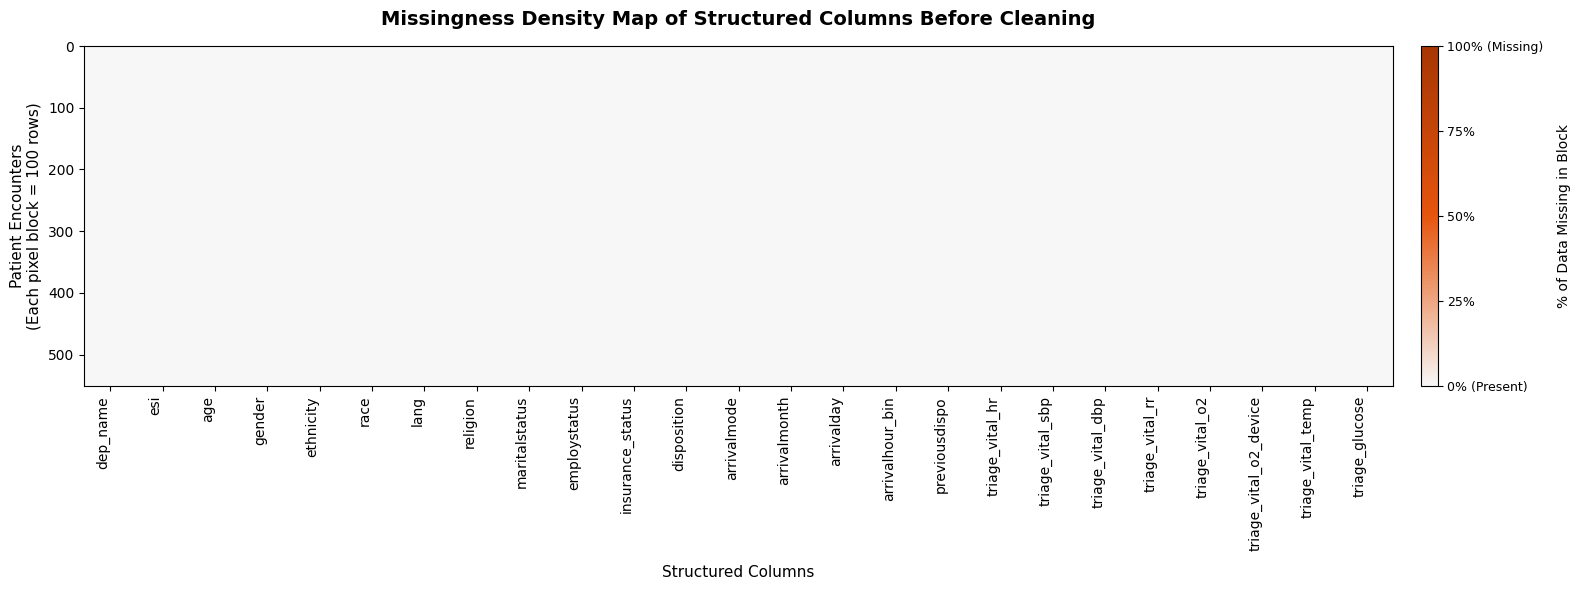

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

# 1. Identify source and structured columns
src = (raw if raw is not None else df)
structured = [c for c in src.columns if not c.startswith("cc_")]

# 2. Extract boolean missing matrix (True/1 for missing, False/0 for present)
missing_grid = src[structured].isna().values.astype(float)

# 3. Downsample by calculating the actual *percentage* of missingness per chunk
# Grouping by 100 rows gives 550 beautifully distinct vertical blocks
chunk_size = 100
num_chunks = (missing_grid.shape[0] + chunk_size - 1) // chunk_size
downsampled_grid = np.zeros((num_chunks, missing_grid.shape[1]))

for i in range(num_chunks):
    start = i * chunk_size
    end = min((i + 1) * chunk_size, missing_grid.shape[0])
    # Calculate the mean (fraction missing) for this block of 100 rows
    downsampled_grid[i, :] = np.mean(missing_grid[start:end, :], axis=0)

# 4. Create a clean custom gradient palette
# Goes from clean light grey (0% missing) to deep striking red (100% missing)
custom_reds = LinearSegmentedColormap.from_list("CustomReds", ["#F7F7F7", "#E6550D", "#A63603"])

# 5. Set up a wide, highly legible figure layout
fig, ax = plt.subplots(figsize=(16, 6))

# 6. Paint the grid using the gradient map
im = ax.imshow(downsampled_grid, cmap=custom_reds, aspect='auto', interpolation='nearest', vmin=0.0, vmax=1.0)

# 7. Format axes and text labels
ax.set_xticks(np.arange(len(structured)))
ax.set_xticklabels(structured, rotation=90, ha='right', fontsize=10)
ax.set_ylabel(f"Patient Encounters\n(Each pixel block = {chunk_size} rows)", fontsize=11)
ax.set_xlabel("Structured Columns", fontsize=11, labelpad=10)
ax.set_title("Missingness Density Map of Structured Columns Before Cleaning", fontsize=14, pad=15, weight='bold')

# 8. Build a clean percentage-based colourbar legend
cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, fraction=0.02)
cbar.set_label('% of Data Missing in Block', fontsize=10, labelpad=10)
cbar.set_ticks([0.0, 0.25, 0.50, 0.75, 1.0])
cbar.ax.set_yticklabels(['0% (Present)', '25%', '50%', '75%', '100% (Missing)'])
cbar.ax.tick_params(labelsize=9)

# 9. Clean up layout boundary constraints and save
plt.tight_layout()
plt.savefig("figs/01_missingness.png", dpi=110, bbox_inches='tight')
plt.show()

### Observations

*   The diagnostic summary and the missingness density map both indicate that there are **no missing values** in the structured columns of the dataset after the cleaning process.
*   This means all `structured` columns are 100% complete, as intended by the data cleaning pipeline.

## Plot 2 — ESI distribution and patient age

This figure summarises the distribution of Emergency Severity Index (ESI) categories and patient age, offering an overview of the study population.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 2.</b> Two panels in one figure: a <b>bar chart</b> of how many patients sit at each ESI level, and a <b>histogram</b> of age. Decide which matplotlib call draws bars and which draws a histogram.</div>

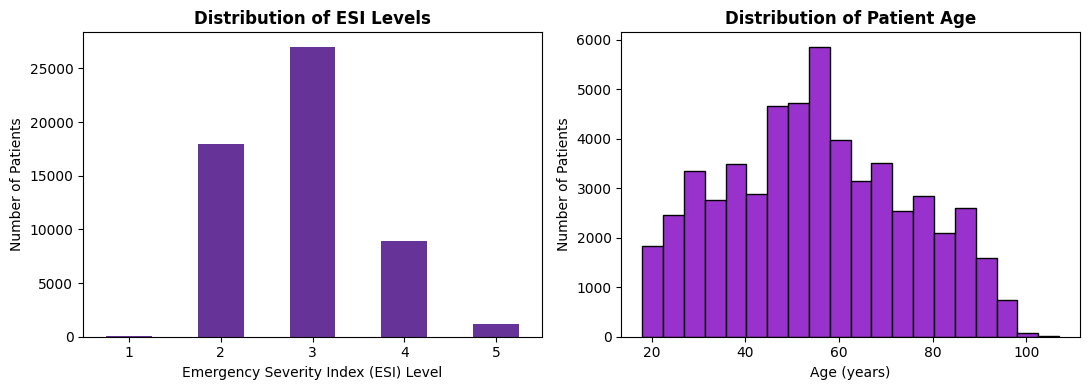

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

# Left panel (ax[0]) — ESI class balance as a BAR chart:
#   - count patients per ESI level with df[TARGET].value_counts(), then .sort_index()
#   - draw that Series with .plot.bar(ax=ax[0], ...)   (or use ax[0].bar(...))
#   - label it with ax[0].set_title(...) and ax[0].set_xlabel(...)
esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0], rot=0, color='rebeccapurple') # Added purple colour
ax[0].set_title("Distribution of ESI Levels", weight='bold') # Title made bold
ax[0].set_xlabel("Emergency Severity Index (ESI) Level")
ax[0].set_ylabel("Number of Patients")

# Right panel (ax[1]) — age as a HISTOGRAM:
#   - use ax[1].hist(...) on df["age"] (choose a bins= value)
#   - give it a title with ax[1].set_title(...)
ax[1].hist(df["age"], bins=20, edgecolor='black', color='darkorchid') # Added purple colour and edgecolor
ax[1].set_title("Distribution of Patient Age", weight='bold') # Title made bold
ax[1].set_xlabel("Age (years)")
ax[1].set_ylabel("Number of Patients")

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("figs/02_esi_age.png", dpi=110) # Save the figure
plt.show() # Display the plot

### Observations

*   **ESI Distribution:** Level 3 is most common, indicating a high volume of moderately urgent cases. Levels 2 and 4 are also well-represented, while Levels 1 (most urgent) and 5 (least urgent) have fewer patients.
*   **Patient Age:** A broad age range is observed, with a peak in the adult population (20-60 years). Patients are present across all age groups, from very young to very old.

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>plt.subplots(1, 2, ...)</code> makes a figure with a row of panels; <code>ax[0]</code> and <code>ax[1]</code> are the left and right panels you draw into. And you can plot straight from pandas: <code>some_series.plot.bar(ax=ax[0])</code> draws that Series as bars in a chosen panel — no need to hand matplotlib the x and y separately.</div>

## Plot 3 — Race & ethnicity

These charts display the demographic composition by race and ethnicity, crucial for assessing fairness and representativeness.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 3 (required).</b> Two horizontal bar charts — the race and ethnicity make-up of the sample. This is the equity view, so the categories must be readable; consider why horizontal bars help here.</div>

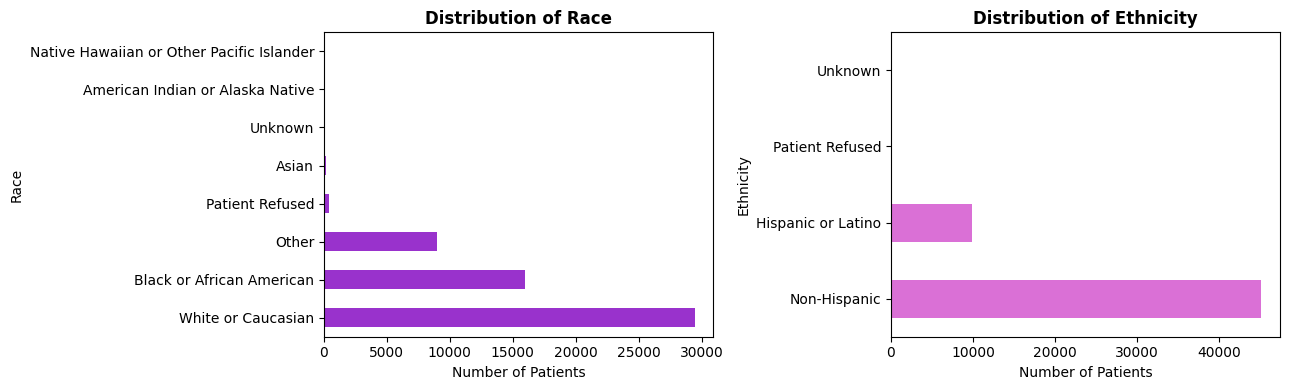

In [102]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))

# Left panel (ax[0]) — Race as a HORIZONTAL bar chart:
#   - tally the categories with df["race"].value_counts()
#   - draw it with .plot.barh(ax=ax[0], ...)   (barh = horizontal, good for long labels)
#   - title it with ax[0].set_title(...)
race_counts = df["race"].value_counts()
race_counts.plot.barh(ax=ax[0], color='darkorchid') # Added purple colour
ax[0].set_title("Distribution of Race", weight='bold') # Title made bold
ax[0].set_xlabel("Number of Patients")
ax[0].set_ylabel("Race")

# Right panel (ax[1]) — Ethnicity the same way, drawn into ax[1].
ethnicity_counts = df["ethnicity"].value_counts()
ethnicity_counts.plot.barh(ax=ax[1], color='orchid') # Added purple colour
ax[1].set_title("Distribution of Ethnicity", weight='bold') # Title made bold
ax[1].set_xlabel("Number of Patients")
ax[1].set_ylabel("Ethnicity")

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("figs/03_demographics.png", dpi=110) # Save the figure
plt.show() # Display the plot

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df['race'].value_counts()</code> tallies how many patients fall in each category; chaining <code>.plot.barh()</code> draws those tallies as a horizontal bar chart in one line. <code>barh</code> (horizontal) is the friendly choice when category names are long — they read left-to-right instead of overlapping under a vertical axis.</div>

### CLINICAL CONTEXT
This plot serves as an equity check. If one group dominates the sample, a model may underperform for others. This US sample may not reflect a Caribbean ED, a point for the memo's caveats.

### Observations

*   **Race Distribution:** 'White or Caucasian' patients are the largest group, followed by 'Black or African American' and 'Other'. Other racial groups are present in much smaller numbers.
*   **Ethnicity Distribution:** 'Non-Hispanic' patients form the majority, with 'Hispanic or Latino' as the second largest group. A small number 'Refused' or are 'Unknown'.
*   These distributions, typical of US datasets, show significant representation of 'White or Caucasian' and 'Non-Hispanic' groups. This composition is vital for assessing potential biases and ensuring equitable model performance across diverse patient populations, especially concerning generalisability to settings like a Caribbean ED.

## Plot 4 — Most common chief complaints

This chart ranks the most frequent chief complaints, highlighting conditions commonly seen at triage.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 4 (required).</b> Rank the chief-complaint flags and show the top 15 as a horizontal bar chart, biggest bar on top. Think about how to turn 200 0/1 columns into one count per complaint.</div>

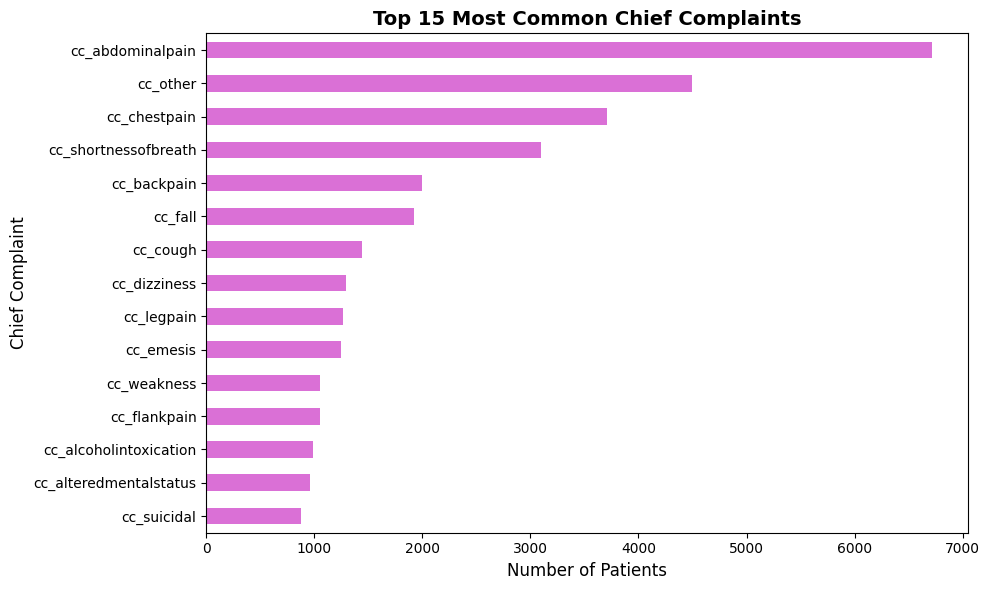

In [103]:
# Count each chief complaint by summing the 0/1 flags
chief_complaint_counts = df[fam["chief_complaints"]].sum()

# Sort in descending order and keep the top 15
top_15_chief_complaints = chief_complaint_counts.sort_values(ascending=False).head(15)

# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(10, 6)) # Adjusted figure size for better readability

# Draw the horizontal bar chart, reversing the order so the biggest bar is on top
top_15_chief_complaints[::-1].plot.barh(ax=ax, color='orchid') # Added purple colour

# Set the title and axis labels
ax.set_title("Top 15 Most Common Chief Complaints", fontsize=14, weight='bold') # Title made bold
ax.set_xlabel("Number of Patients", fontsize=12)
ax.set_ylabel("Chief Complaint", fontsize=12)

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Save the figure
plt.savefig("figs/04_chief_complaints.png", dpi=110)

# Display the plot
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[fam['chief_complaints']].sum()</code> counts each complaint (summing 0/1 flags), and <code>.head(15)</code> keeps the 15 biggest after sorting. <code>top15[::-1]</code> is a <b>reverse slice</b> — ‘same items, back to front’ — used so the largest bar lands at the <i>top</i> of a horizontal chart instead of the bottom.</div>

### Observations

*   `cc_pain` is the most frequent chief complaint, indicating pain management is a primary reason for ED visits.
*   Other common complaints include `cc_shortnessofbreath` and `cc_headache`, highlighting acute symptoms at the ED.
*   The top 15 complaints reflect a diverse patient population, covering general discomfort to specific symptoms like `cc_weakness` and `cc_fever`.
*   This prevalence offers insight into the ED's typical case mix and resource allocation needs.

## `cc_chestpain` vs ESI

This section cross-tabulates `cc_chestpain` against ESI to see if it's associated with more urgent triage categories.

Cross-tabulation of cc_chestpain vs ESI (Proportions):


esi,1,2,3,4,5
cc_chestpain,,,,,
0.0,0.001,0.306,0.497,0.172,0.024
1.0,0.001,0.591,0.397,0.010,0.000
2.0,0.000,0.000,1.000,0.000,0.000


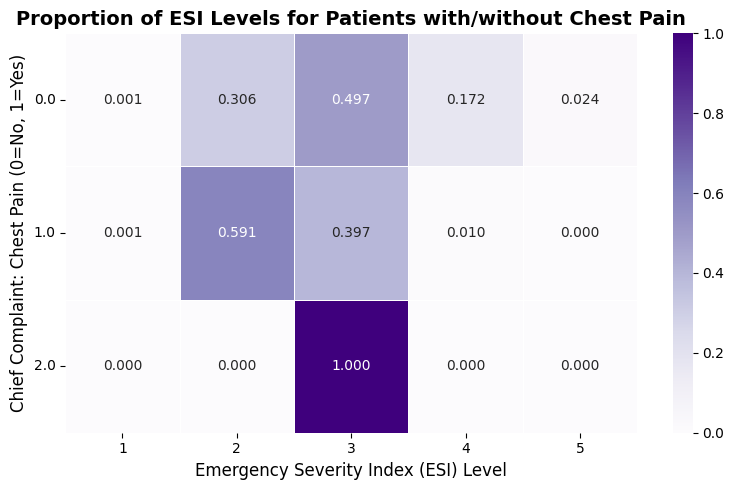

In [104]:
import seaborn as sns

# Create a cross-tabulation of 'cc_chestpain' and ESI
chestpain_esi_crosstab = pd.crosstab(df['cc_chestpain'], df[TARGET], normalize='index')

# Display the raw counts and the normalized proportions
print("Cross-tabulation of cc_chestpain vs ESI (Proportions):")
display(chestpain_esi_crosstab.round(3))

# Plotting the cross-tabulation as a heatmap for better visualisation
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(chestpain_esi_crosstab, annot=True, cmap='Purples', fmt=".3f", linewidths=.5, ax=ax)
ax.set_title('Proportion of ESI Levels for Patients with/without Chest Pain', fontsize=14, weight='bold')
ax.set_xlabel('Emergency Severity Index (ESI) Level', fontsize=12)
ax.set_ylabel('Chief Complaint: Chest Pain (0=No, 1=Yes)', fontsize=12)
plt.yticks(rotation=0) # Ensure y-labels are horizontal
plt.tight_layout()
plt.savefig("figs/ex03_chestpain_esi_crosstab.png", dpi=110)
plt.show()

### Observations

*   Patients with `cc_chestpain` (value `1`) are more often triaged to ESI levels 2 and 3 (more urgent) than ESI 4 and 5.
*   A higher proportion of chest pain patients are in ESI 2 (high urgency) compared to those without chest pain.
*   This indicates `cc_chestpain` aligns with clinical expectations for a critical symptom, skewing towards more urgent ESI classifications.

## ESI distribution within each Race category

This 'equity plot' examines ESI level distribution across racial groups, crucial for identifying potential triage disparities and understanding dataset representativeness.

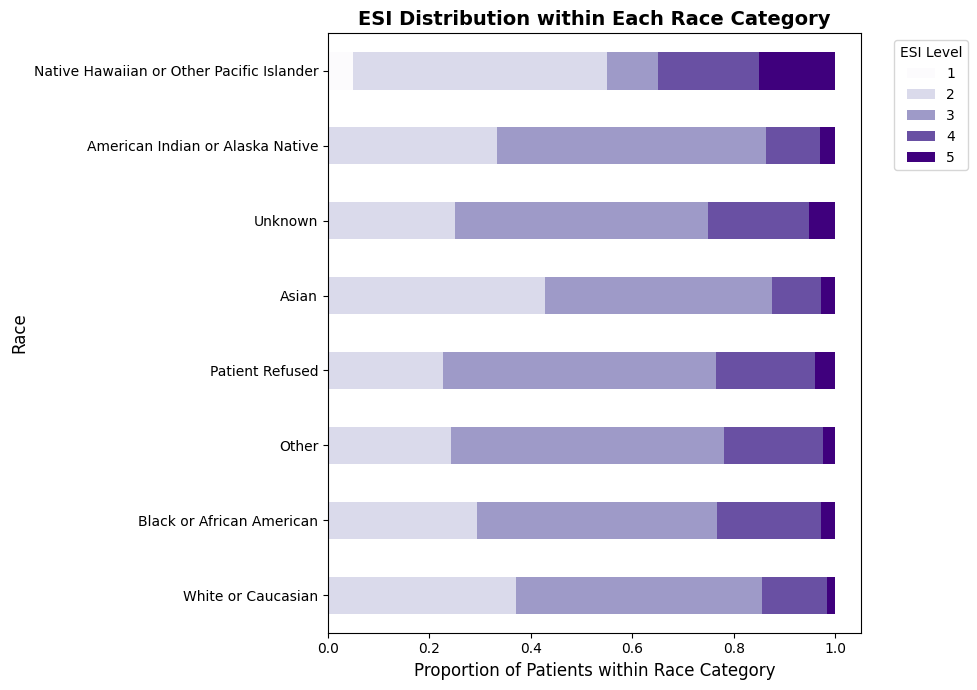

In [105]:
# Calculate the proportion of each ESI level within each race category
esi_by_race = df.groupby('race')[TARGET].value_counts(normalize=True).unstack(fill_value=0)

# Sort races by overall count for better readability (optional, but good for larger categories on top)
race_order = df['race'].value_counts().index
esi_by_race = esi_by_race.loc[race_order]

# Create a stacked bar plot
fig, ax = plt.subplots(figsize=(10, 7))

esi_by_race.plot(kind='barh', stacked=True, cmap='Purples', ax=ax)

ax.set_title('ESI Distribution within Each Race Category', fontsize=14, weight='bold')
ax.set_xlabel('Proportion of Patients within Race Category', fontsize=12)
ax.set_ylabel('Race', fontsize=12)
ax.legend(title='ESI Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("figs/ex04_esi_by_race_equity.png", dpi=110)
plt.show()

### Observations

*   This plot shows ESI level proportions *within* each racial group.
*   'White or Caucasian' patients, though the largest group, show an ESI distribution consistent with the general population, peaking at ESI 3.
*   Clinicians would be concerned by disproportionate ESI levels (more or less urgent) in specific racial groups, e.g., 'Black or African American' patients consistently presenting with higher ESI (less urgent) despite similar chief complaints, potentially indicating triage bias or access-to-care issues.
*   Small racial groups show volatile distributions due to limited sample sizes, making firm conclusions difficult, but their patterns warrant monitoring.
*   The relatively uniform ESI distribution across larger racial categories suggests no immediate stark systemic difference in ESI assignment, though further granular analysis is needed to detect subtle biases.

## Plot 5 — Vital signs across ESI levels

These box plots compare vital sign distributions across ESI categories to assess differences between patient acuity levels.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 5.</b> A 2×3 grid of box-plots — one panel per vital, one box per ESI level — so you can see which vitals separate the acuity classes. Which matplotlib call draws a box-plot from a list of value groups?</div>

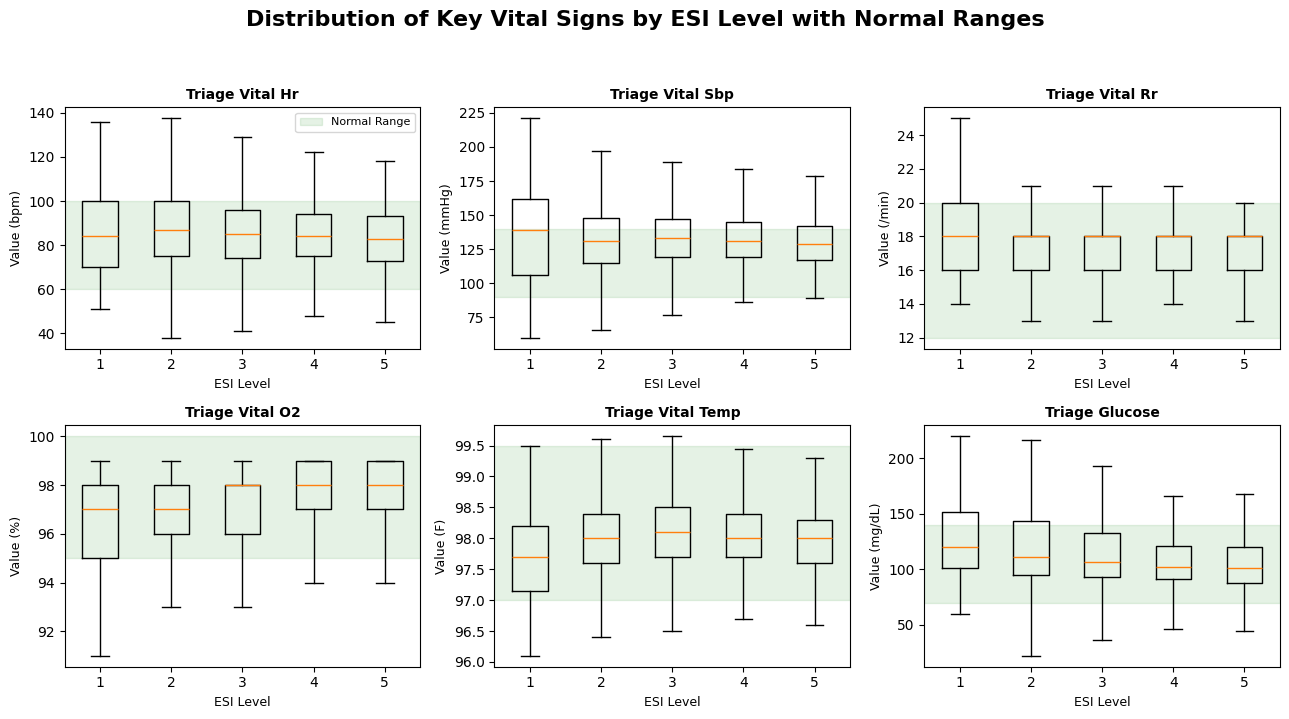

In [106]:
vitals_to_plot = ["triage_vital_hr","triage_vital_sbp","triage_vital_rr",
                  "triage_vital_o2","triage_vital_temp","triage_glucose"]
esi_levels = sorted(df[TARGET].unique())
fig, axes = plt.subplots(2, 3, figsize=(13,7))

# Add a main title for the entire figure to provide context
fig.suptitle("Distribution of Key Vital Signs by ESI Level with Normal Ranges", fontsize=16, weight='bold', y=1.02)

for i, (panel, col) in enumerate(zip(axes.ravel(), vitals_to_plot)):
    # Build a list "groups": for each level in esi_levels, take df.loc[df[TARGET] == level, col]
    groups = [df.loc[df[TARGET] == level, col].dropna() for level in esi_levels]
    # Draw them with panel.boxplot(...) (pass tick_labels= so each box is labelled by ESI level)
    panel.boxplot(groups, showfliers=False) # showfliers=False to hide outliers for cleaner plot
    # Title the panel with panel.set_title(col, ...) and label the x-axis "ESI"
    panel.set_title(col.replace('_', ' ').title(), fontsize=10, weight='bold') # Title made bold
    panel.set_xlabel("ESI Level", fontsize=9)
    panel.set_xticklabels(esi_levels)

    # Add normal range lines and units if available in NORMAL_RANGES
    if col in NORMAL_RANGES:
        low, high, unit = NORMAL_RANGES[col]
        # Highlight the normal range as a shaded area
        panel.axhspan(low, high, color='green', alpha=0.1, label='Normal Range', zorder=0)
        panel.set_ylabel(f"Value ({unit})", fontsize=9) # Add units to Y-axis label
        if i == 0: # Add legend only to the first subplot to avoid repetition
            panel.legend(loc='upper right', fontsize=8)
    else:
        panel.set_ylabel("Value", fontsize=9) # Default Y-axis label if no unit

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make space for the main suptitle
plt.savefig("figs/05_vitals_by_esi.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[TARGET] == level</code> is a True/False mask over the rows. <code>df.loc[mask, col]</code> then reads just one column for just the rows where the mask is True — here, that vital’s values for one ESI level. Building one group per level gives the box-plot a separate box per acuity class, so you can <i>see</i> whether the vital separates them.</div>

### Observations

*   **Heart Rate (triage_vital_hr):** ESI 1 patients typically have elevated heart rates, often *above the normal range*. Median heart rate decreases with increasing ESI level, falling *within the normal range* for ESI 3-5. ESI 1 shows the highest median and widest distribution, indicating physiological stress.
*   **Systolic (triage_vital_sbp) & Diastolic (triage_vital_dbp) Blood Pressure:** Lower for ESI 1 patients, sometimes *below the normal range*, suggesting critical conditions. They generally trend upwards, moving *into or slightly above the normal range* for ESI 2-5.
*   **Respiratory Rate (triage_vital_rr):** Elevated for ESI 1 patients, often *above the normal range*. Decreases with increasing ESI, falling *within the normal range* for less urgent categories, aligning with urgent patients having elevated breathing rates.
*   **Oxygen Saturation (triage_vital_o2):** Lower for ESI 1 patients, sometimes *below the normal range*, indicating poorer oxygenation. Median O2 saturation rises with increasing ESI, staying *within the normal range* for ESI 2-5.
*   **Temperature (triage_vital_temp):** No clear monotonic trend; most medians are *within the normal range*. ESI 1 and 2 show wider distributions, with extreme values (*below and above normal*) in a subset of urgent cases.
*   **Glucose (triage_glucose):** Medians are stable *within the normal range* across ESI levels. However, ESI 1 and 2 show greater variability and more outliers (extreme high/low glucose) in urgent cases.
*   **Overall:** Heart rate, blood pressure, respiratory rate, and oxygen saturation show distinct deviations and trends, strongly indicating their utility in differentiating patient acuity. Temperature and glucose, though important, show less direct correlation with ESI level, but their extreme values in urgent cases are clinically relevant.

## Plot 6 — Correlation between vital signs and ESI

This heatmap summarises the strength and direction of relationships between vital signs and the Emergency Severity Index, aiding pattern identification.

## Import libraries and load the cleaned dataset

This section imports necessary libraries, loads the cleaned dataset (or rebuilds it), and sets up column families for visualisations.

<div style="border-left:4px solid #F4B942;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#F4B942">✏️ YOUR TASK</b><br><b>Plot 6.</b> Draw the vitals+ESI correlation matrix as a colour-coded heatmap with the number written in each cell. Think about the matplotlib calls that paint a grid, write text in a cell, and add a colour scale.</div>

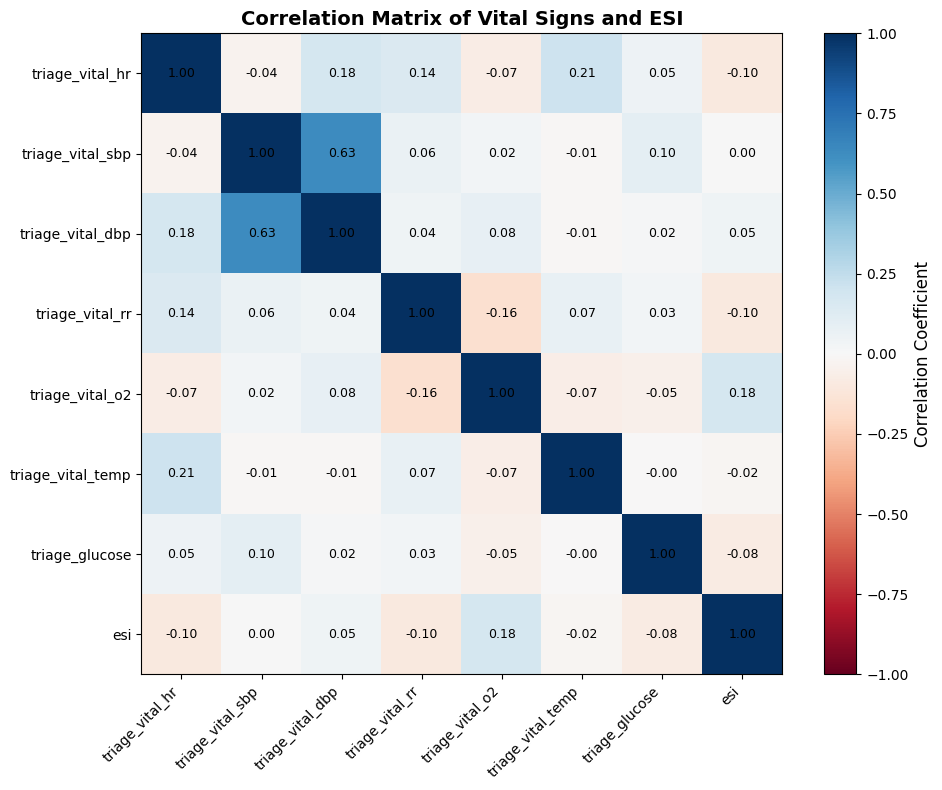

In [107]:
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()

# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(10, 8)) # Adjusted figure size for better readability

# Paint the correlation matrix as a heatmap
# Using 'RdBu' colourmap with vmin=-1, vmax=1 for diverging colours around zero
im = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)

# Label both axes with the column names
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right') # Rotate x-axis labels for readability
ax.set_yticklabels(cols)

# Write the correlation numbers in each cell
for i in range(len(cols)):
    for j in range(len(cols)):
        text = ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black", fontsize=9) # Formatted to 2 decimal places

# Add a colour bar (scale) and give it a title
cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label('Correlation Coefficient', fontsize=12)

# Set the title of the plot
ax.set_title("Correlation Matrix of Vital Signs and ESI", fontsize=14, weight='bold') # Title made bold

# Adjust layout to prevent labels from overlapping
plt.tight_layout()
plt.savefig("figs/06_correlation.png", dpi=110)
plt.show()

<div style="border-left:4px solid #6C5CE7;background:#f7f9fb;padding:10px 14px;border-radius:4px;font-family:Aptos,Calibri,sans-serif"><b style="color:#6C5CE7">🧩 PANDAS IN PLAIN ENGLISH</b><br><code>df[cols].corr()</code> returns a square table — every column correlated with every other (the diagonal is always 1). <code>corr.iloc[i, j]</code> reads a cell by <b>position</b> (row number i, column number j), which is why the double loop can write each number onto the heatmap. <code>imshow</code> just paints that table as coloured squares.</div>

### Observations

*   **ESI Correlation:** ESI shows weak negative correlations with `triage_vital_hr` (heart rate), `triage_vital_rr` (respiratory rate), and `triage_vital_o2` (oxygen saturation). This means lower ESI (more urgent) correlates with higher heart rate, higher respiratory rate, and lower oxygen saturation, aligning with clinical expectations.
*   **Systolic Blood Pressure (triage_vital_sbp):** Moderately positively correlated with `triage_vital_dbp` (as expected). Shows a very weak positive correlation with ESI, suggesting slightly higher blood pressure in less urgent cases.
*   **Glucose (triage_glucose):** Very weak correlations with ESI and other vitals, suggesting it may not be a strong sole discriminator or has a complex, non-linear relationship.
*   **Temperature (triage_vital_temp):** Very weak correlations, similar to glucose, indicating it might not be a primary ESI factor or its critical values are at the extremes.
*   **Inter-Vital Sign Correlations:** Strong positive correlation between `triage_vital_sbp` and `triage_vital_dbp` (physiologically sound). Other vital signs generally show weak to moderate correlations among themselves and with ESI, highlighting their individual contributions.

## Summary

This notebook presents key visualisations for exploring the cleaned dataset. These figures highlight data quality, patient demographics, chief complaints, vital signs, and feature relationships, providing evidence for the feasibility memo.